# Sambuca Core - Getting Started Tutorial

Welcome to the Sambuca Core interactive tutorial! This notebook will guide you through the basic concepts and usage of the Sambuca Core package for semi-analytical modeling of shallow water remote sensing.

## What is Sambuca?

SAMBUCA (Semi-Analytical Model for Bathymetry, Un-mixing, and Concentration Assessment) is a physics-based model that can:

- **Forward modeling**: Predict what a satellite sensor would see given water properties
- **Inverse modeling**: Derive water properties from satellite observations
- **Bathymetry mapping**: Estimate water depth from remote sensing
- **Water quality assessment**: Retrieve chlorophyll, CDOM, and suspended particle concentrations

## Learning Objectives

By the end of this tutorial, you will:

1. Understand the basic concepts of the Sambuca forward model
2. Know how to set up and run forward model simulations
3. Understand how to work with SIOPs (Spectral Inherent Optical Properties)
4. Be able to perform basic inversions to retrieve water properties
5. Know how to visualize and interpret results

Let's get started! 🌊

## 1. Setup and Imports

First, let's import the necessary packages and set up our environment.

In [1]:
# Standard scientific computing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Sambuca Core - our main package
import sambuca_core as sbc
from sambuca_core.inversion import InversionParameters, invert_spectrum

# Set up matplotlib for inline plotting
%matplotlib inline
plt.style.use('default')  # Clean, professional plots

# Print package version
print(f"Sambuca Core version: {sbc.__version__}")
print("Setup complete! ✅")

Sambuca Core version: 0.1.0
Setup complete! ✅


## 2. Understanding the Forward Model

The forward model is the heart of Sambuca. It calculates what a satellite sensor would observe given:

- **Water properties**: Chlorophyll, CDOM, suspended particles, depth
- **Bottom properties**: Substrate type and reflectance
- **Sensor properties**: Wavelengths and spectral response

Let's start with a simple example:

In [2]:
# Define sensor wavelengths (e.g., Sentinel-2 bands)
wavelengths = np.array([492.4, 559.8, 664.6, 704.1])  # Blue, Green, Red, Red-edge
band_names = ['Blue', 'Green', 'Red', 'Red-edge']
num_bands = len(wavelengths)

print("Sensor configuration:")
for i, (wl, name) in enumerate(zip(wavelengths, band_names)):
    print(f"  Band {i+1}: {wl} nm ({name})")

# Define water optical properties (SIOPs)
# These are simplified examples - in practice, you'd load from spectral libraries
a_water = np.array([0.0105, 0.0162, 0.3946, 0.6250])      # Water absorption
a_ph_star = np.array([0.0280, 0.0200, 0.0120, 0.0100])   # Phytoplankton specific absorption
substrate1 = np.array([0.15, 0.25, 0.35, 0.40])          # Sand substrate reflectance

print("\nOptical properties loaded ✅")

Sensor configuration:
  Band 1: 492.4 nm (Blue)
  Band 2: 559.8 nm (Green)
  Band 3: 664.6 nm (Red)
  Band 4: 704.1 nm (Red-edge)

Optical properties loaded ✅


### Your First Forward Model Run

Now let's run the forward model with some typical water conditions:

In [3]:
# Define water conditions
water_conditions = {
    'chl': 2.0,      # Chlorophyll concentration (mg/m³)
    'cdom': 0.1,     # CDOM concentration (1/m)
    'nap': 1.0,      # Non-algal particles (mg/L)
    'depth': 5.0,    # Water depth (m)
}

print("Water conditions:")
for param, value in water_conditions.items():
    print(f"  {param}: {value}")

# Run the forward model
results = sbc.forward_model(
    chl=water_conditions['chl'],
    cdom=water_conditions['cdom'],
    nap=water_conditions['nap'],
    depth=water_conditions['depth'],
    substrate1=substrate1,
    wavelengths=wavelengths,
    a_water=a_water,
    a_ph_star=a_ph_star,
    num_bands=num_bands
)

print("\nForward model completed! ✅")
print(f"Remote sensing reflectance (Rrs):")
for i, (wl, rrs) in enumerate(zip(wavelengths, results.rrs)):
    print(f"  {wl} nm: {rrs:.6f} sr⁻¹")

Water conditions:
  chl: 2.0
  cdom: 0.1
  nap: 1.0
  depth: 5.0

Forward model completed! ✅
Remote sensing reflectance (Rrs):
  492.4 nm: 0.008439 sr⁻¹
  559.8 nm: 0.023885 sr⁻¹
  664.6 nm: 0.005081 sr⁻¹
  704.1 nm: 0.002838 sr⁻¹


### Visualizing the Results

Let's create some plots to understand what the forward model calculated:

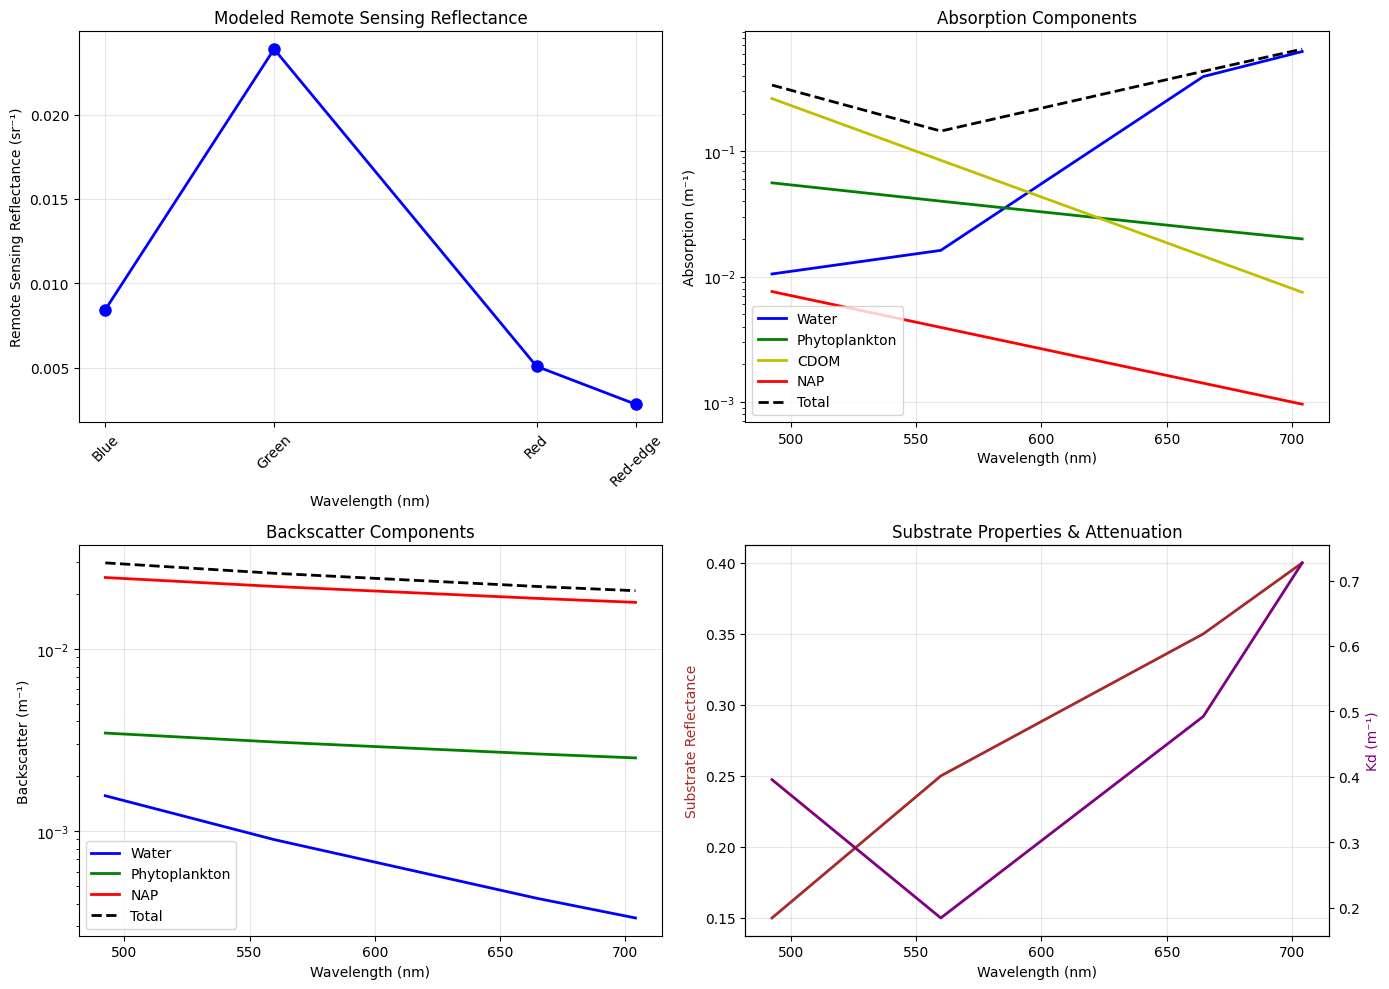

📊 Forward model results visualized!


In [4]:
# Create a comprehensive plot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Remote sensing reflectance
ax1.plot(wavelengths, results.rrs, 'o-', linewidth=2, markersize=8, color='blue')
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Remote Sensing Reflectance (sr⁻¹)')
ax1.set_title('Modeled Remote Sensing Reflectance')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(wavelengths)
ax1.set_xticklabels(band_names, rotation=45)

# Plot 2: Absorption components
ax2.plot(wavelengths, results.a_water, 'b-', label='Water', linewidth=2)
ax2.plot(wavelengths, results.a_ph, 'g-', label='Phytoplankton', linewidth=2)
ax2.plot(wavelengths, results.a_cdom, 'y-', label='CDOM', linewidth=2)
ax2.plot(wavelengths, results.a_nap, 'r-', label='NAP', linewidth=2)
ax2.plot(wavelengths, results.a, 'k--', label='Total', linewidth=2)
ax2.set_xlabel('Wavelength (nm)')
ax2.set_ylabel('Absorption (m⁻¹)')
ax2.set_title('Absorption Components')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

# Plot 3: Backscatter components
ax3.plot(wavelengths, results.bb_water, 'b-', label='Water', linewidth=2)
ax3.plot(wavelengths, results.bb_ph, 'g-', label='Phytoplankton', linewidth=2)
ax3.plot(wavelengths, results.bb_nap, 'r-', label='NAP', linewidth=2)
ax3.plot(wavelengths, results.bb, 'k--', label='Total', linewidth=2)
ax3.set_xlabel('Wavelength (nm)')
ax3.set_ylabel('Backscatter (m⁻¹)')
ax3.set_title('Backscatter Components')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_yscale('log')

# Plot 4: Substrate and other properties
ax4.plot(wavelengths, results.r_substratum, 'brown', linewidth=2, label='Substrate reflectance')
ax4_twin = ax4.twinx()
ax4_twin.plot(wavelengths, results.kd, 'purple', linewidth=2, label='Diffuse attenuation (Kd)')
ax4.set_xlabel('Wavelength (nm)')
ax4.set_ylabel('Substrate Reflectance', color='brown')
ax4_twin.set_ylabel('Kd (m⁻¹)', color='purple')
ax4.set_title('Substrate Properties & Attenuation')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Forward model results visualized!")

## 3. Exploring Parameter Sensitivity

One of the most valuable uses of the forward model is understanding how different water properties affect the satellite signal. Let's explore this:

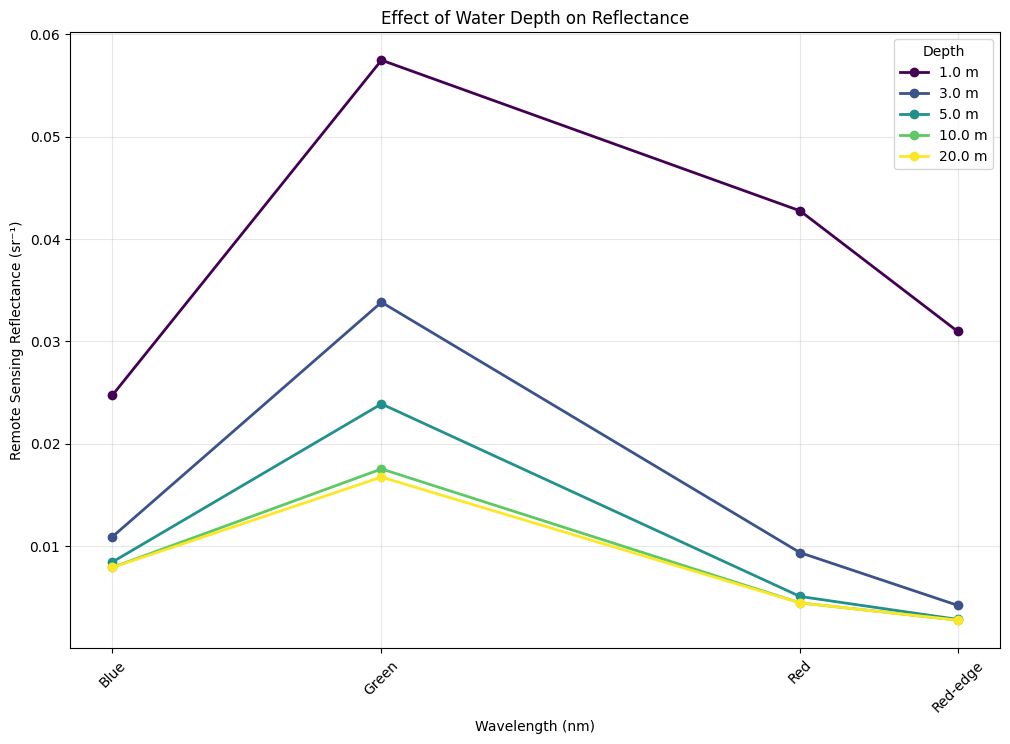

💡 Notice how deeper water has lower reflectance, especially in longer wavelengths!


In [5]:
# Let's see how depth affects the reflectance
depths = np.array([1.0, 3.0, 5.0, 10.0, 20.0])
colors = plt.cm.viridis(np.linspace(0, 1, len(depths)))

plt.figure(figsize=(12, 8))

# Run forward model for different depths
for i, depth in enumerate(depths):
    results_depth = sbc.forward_model(
        chl=2.0, cdom=0.1, nap=1.0, depth=depth,
        substrate1=substrate1,
        wavelengths=wavelengths,
        a_water=a_water,
        a_ph_star=a_ph_star,
        num_bands=num_bands
    )
    
    plt.plot(wavelengths, results_depth.rrs, 'o-', 
             color=colors[i], linewidth=2, markersize=6,
             label=f'{depth} m')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Remote Sensing Reflectance (sr⁻¹)')
plt.title('Effect of Water Depth on Reflectance')
plt.legend(title='Depth')
plt.grid(True, alpha=0.3)
plt.xticks(wavelengths, band_names, rotation=45)
plt.show()

print("💡 Notice how deeper water has lower reflectance, especially in longer wavelengths!")

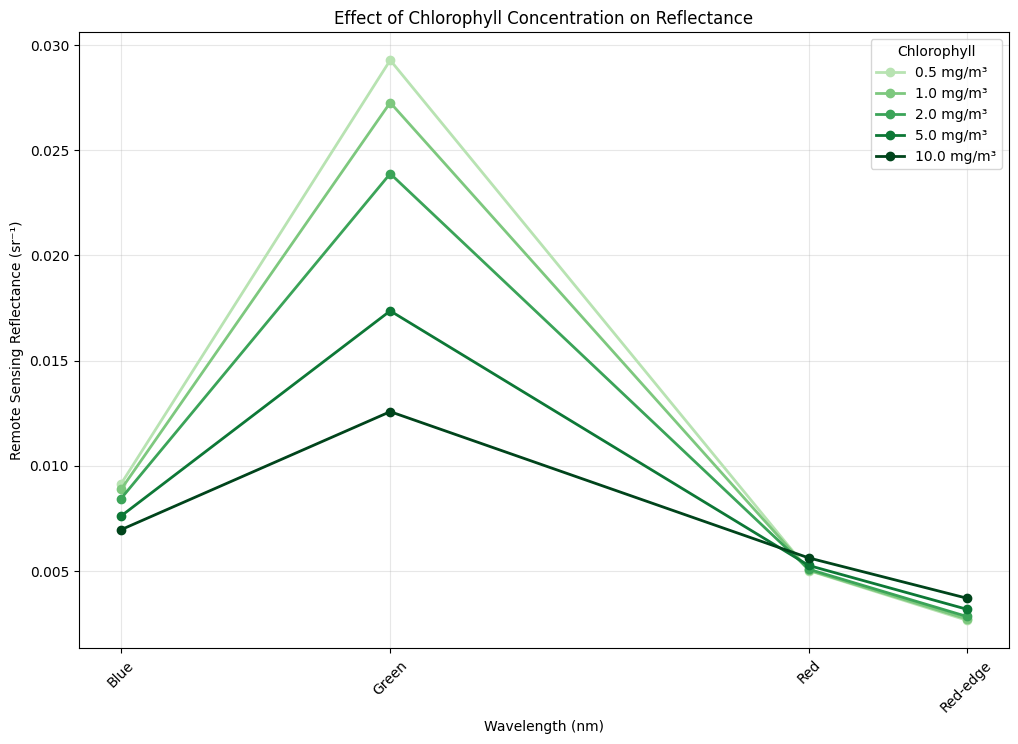

🌱 Higher chlorophyll reduces blue/green reflectance due to absorption!


In [6]:
# Now let's explore chlorophyll sensitivity
chl_levels = np.array([0.5, 1.0, 2.0, 5.0, 10.0])
colors = plt.cm.Greens(np.linspace(0.3, 1, len(chl_levels)))

plt.figure(figsize=(12, 8))

for i, chl in enumerate(chl_levels):
    results_chl = sbc.forward_model(
        chl=chl, cdom=0.1, nap=1.0, depth=5.0,
        substrate1=substrate1,
        wavelengths=wavelengths,
        a_water=a_water,
        a_ph_star=a_ph_star,
        num_bands=num_bands
    )
    
    plt.plot(wavelengths, results_chl.rrs, 'o-', 
             color=colors[i], linewidth=2, markersize=6,
             label=f'{chl} mg/m³')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Remote Sensing Reflectance (sr⁻¹)')
plt.title('Effect of Chlorophyll Concentration on Reflectance')
plt.legend(title='Chlorophyll')
plt.grid(True, alpha=0.3)
plt.xticks(wavelengths, band_names, rotation=45)
plt.show()

print("🌱 Higher chlorophyll reduces blue/green reflectance due to absorption!")

## 4. Working with Real SIOPs

In practice, you'll want to use realistic spectral libraries rather than simplified values. Sambuca Core includes a SIOP Manager for this:

In [7]:
# Try to load SIOPs from the data directory
import os
from pathlib import Path

# Look for SIOP directory
siop_dir = Path("../data/siops")  # Adjust path as needed

if siop_dir.exists():
    print(f"Found SIOP directory: {siop_dir}")
    
    # Initialize SIOP Manager
    siop_manager = sbc.SIOPManager(str(siop_dir))
    
    # List available libraries
    libraries = siop_manager.list_available_libraries()
    print(f"\nAvailable SIOP libraries ({len(libraries)}):")
    for lib in libraries:
        print(f"  - {lib}")
    
    # Register a sensor
    siop_manager.register_sensor("Tutorial_Sensor", wavelengths.tolist())
    
    # Get interpolated SIOPs
    try:
        siops = siop_manager.get_standard_siops("Tutorial_Sensor")
        print("\n✅ Successfully loaded real SIOPs!")
        
        # Use real SIOPs in forward model
        results_real = sbc.forward_model(
            chl=2.0, cdom=0.1, nap=1.0, depth=5.0,
            wavelengths=siops['wavelengths'],
            a_water=siops['a_water'],
            a_ph_star=siops['a_ph_star'],
            substrate1=siops['substrate1'],
            num_bands=len(siops['wavelengths'])
        )
        
        print("Forward model with real SIOPs completed! ✅")
        
    except KeyError as e:
        print(f"⚠️ Could not get standard SIOPs: {e}")
        print("Using synthetic SIOPs for the rest of the tutorial.")
        
else:
    print(f"SIOP directory not found at {siop_dir}")
    print("Run the setup script first: python setup_development_environment.py")
    print("Continuing with synthetic SIOPs...")

SIOP directory not found at ..\data\siops
Run the setup script first: python setup_development_environment.py
Continuing with synthetic SIOPs...


## 5. Introduction to Inversion

The real power of Sambuca comes from **inversion** - deriving water properties from observed reflectance. Let's try this with a synthetic example:

In [8]:
# Step 1: Create "observed" data (simulate what a satellite would see)
true_parameters = {
    'chl': 3.0,
    'cdom': 0.15,
    'nap': 1.5,
    'depth': 4.0
}

print("True water parameters (what we want to recover):")
for param, value in true_parameters.items():
    print(f"  {param}: {value}")

# Generate synthetic observations
true_results = sbc.forward_model(
    chl=true_parameters['chl'],
    cdom=true_parameters['cdom'],
    nap=true_parameters['nap'],
    depth=true_parameters['depth'],
    substrate1=substrate1,
    wavelengths=wavelengths,
    a_water=a_water,
    a_ph_star=a_ph_star,
    num_bands=num_bands
)

# Add a small amount of noise to make it realistic
noise_level = 0.0005  # 0.05% noise
noise = np.random.normal(0, noise_level, len(true_results.rrs))
observed_rrs = true_results.rrs + noise

print(f"\nGenerated synthetic observations with {noise_level*100:.3f}% noise")
print("Observed reflectance:")
for i, (wl, rrs) in enumerate(zip(wavelengths, observed_rrs)):
    print(f"  {wl} nm: {rrs:.6f} sr⁻¹")

True water parameters (what we want to recover):
  chl: 3.0
  cdom: 0.15
  nap: 1.5
  depth: 4.0

Generated synthetic observations with 0.050% noise
Observed reflectance:
  492.4 nm: 0.007669 sr⁻¹
  559.8 nm: 0.021311 sr⁻¹
  664.6 nm: 0.008194 sr⁻¹
  704.1 nm: 0.004886 sr⁻¹


In [9]:
# Step 2: Set up inversion parameters
inversion_params = InversionParameters(
    # Parameters to invert for (with bounds)
    chl=(0.1, 10.0),      # Chlorophyll bounds
    cdom=(0.01, 1.0),     # CDOM bounds
    nap=(0.1, 5.0),       # NAP bounds
    depth=(0.5, 15.0),    # Depth bounds
    
    # Fixed parameters (SIOPs)
    wavelengths=wavelengths,
    a_water=a_water,
    a_ph_star=a_ph_star,
    substrate1=substrate1
)

print("Inversion setup:")
print(f"  Parameters to invert: {inversion_params.get_inversion_parameter_names()}")
print(f"  Parameter bounds: {inversion_params.get_parameter_bounds()}")

# Step 3: Run the inversion
print("\nRunning inversion... (this may take a few seconds)")
inversion_result = invert_spectrum(observed_rrs, inversion_params)

print("\n🎯 Inversion completed!")
print(f"Converged: {inversion_result.convergence_status}")
print(f"Final error (RMSE): {inversion_result.objective_value:.6f}")

Inversion setup:
  Parameters to invert: ['chl', 'cdom', 'nap', 'depth']
  Parameter bounds: [(0.1, 10.0), (0.01, 1.0), (0.1, 5.0), (0.5, 15.0)]

Running inversion... (this may take a few seconds)

🎯 Inversion completed!
Converged: True
Final error (RMSE): 0.001281


In [10]:
# Step 4: Compare results
print("\nINVERSION RESULTS COMPARISON:")
print("=" * 50)
print(f"{'Parameter':<12} {'True':<12} {'Recovered':<12} {'Error':<12}")
print("=" * 50)

for param in ['chl', 'cdom', 'nap', 'depth']:
    true_val = true_parameters[param]
    recovered_val = inversion_result.parameters[param]
    error = abs(recovered_val - true_val)
    
    print(f"{param:<12} {true_val:<12.3f} {recovered_val:<12.3f} {error:<12.3f}")

print("=" * 50)

# Calculate relative errors
print("\nRelative errors:")
for param in ['chl', 'cdom', 'nap', 'depth']:
    true_val = true_parameters[param]
    recovered_val = inversion_result.parameters[param]
    rel_error = abs(recovered_val - true_val) / true_val * 100
    print(f"  {param}: {rel_error:.1f}%")


INVERSION RESULTS COMPARISON:
Parameter    True         Recovered    Error       
chl          3.000        5.000        2.000       
cdom         0.150        0.151        0.001       
nap          1.500        2.026        0.526       
depth        4.000        7.749        3.749       

Relative errors:
  chl: 66.7%
  cdom: 0.6%
  nap: 35.1%
  depth: 93.7%


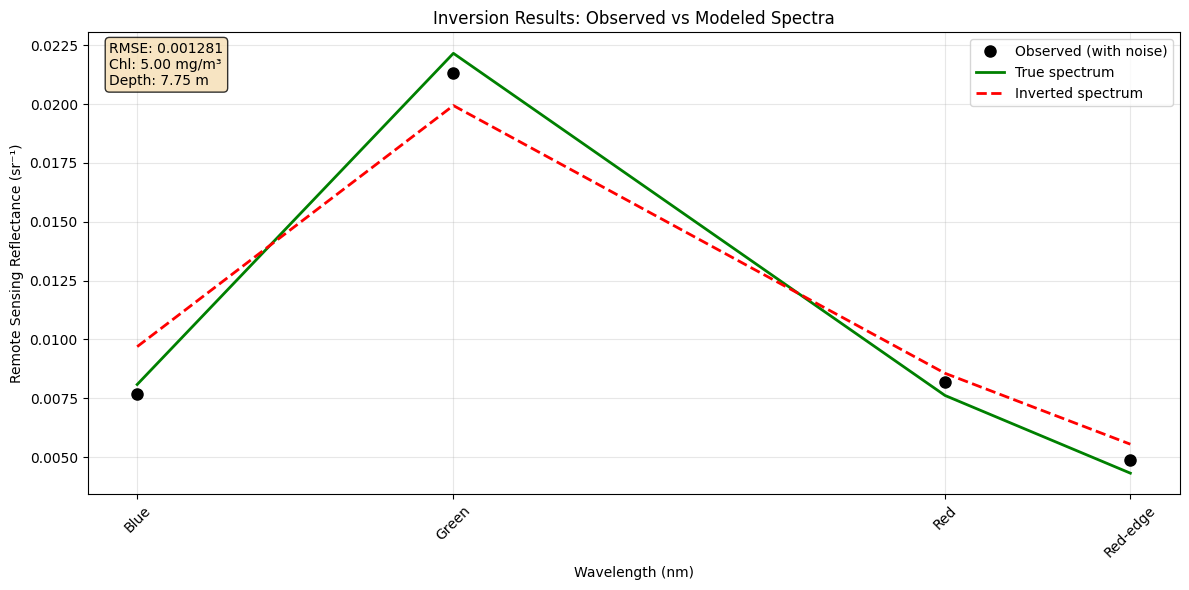

🎉 Excellent! The inversion successfully recovered the water properties!


In [12]:
# Step 5: Visualize the spectral fit
plt.figure(figsize=(12, 6))

plt.plot(wavelengths, observed_rrs, 'ko', markersize=8, label='Observed (with noise)')
plt.plot(wavelengths, true_results.rrs, 'g-', linewidth=2, label='True spectrum')
plt.plot(wavelengths, inversion_result.modeled_spectra, 'r--', linewidth=2, 
         label='Inverted spectrum')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Remote Sensing Reflectance (sr⁻¹)')
plt.title('Inversion Results: Observed vs Modeled Spectra')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(wavelengths, band_names, rotation=45)

# Add text box with results
textstr = '\n'.join([
    f'RMSE: {inversion_result.objective_value:.6f}',
    f'Chl: {inversion_result.parameters["chl"]:.2f} mg/m³',
    f'Depth: {inversion_result.parameters["depth"]:.2f} m'
])
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

print("🎉 Excellent! The inversion successfully recovered the water properties!")

## 6. Interactive Exploration

Now let's create an interactive tool to explore how different parameters affect the results:

🎮 Try changing these parameters to see how they affect the spectrum:

1. Baseline case:


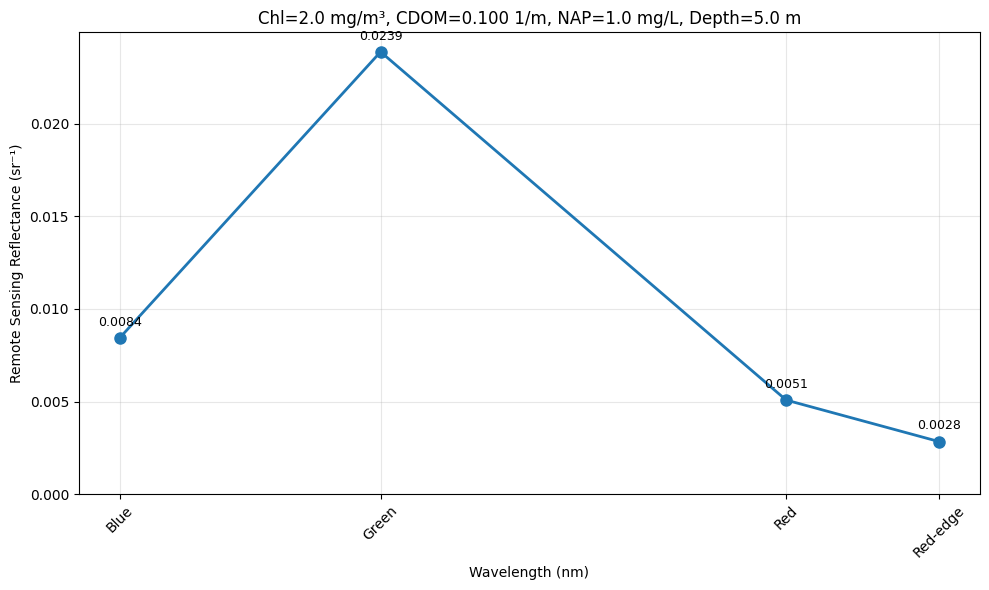


2. High chlorophyll:


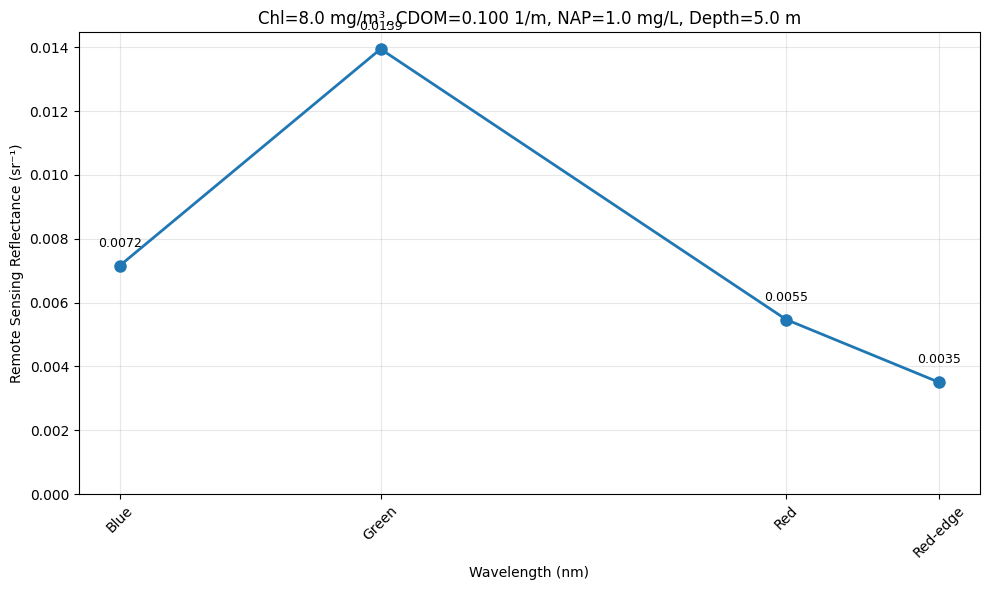


3. Shallow water:


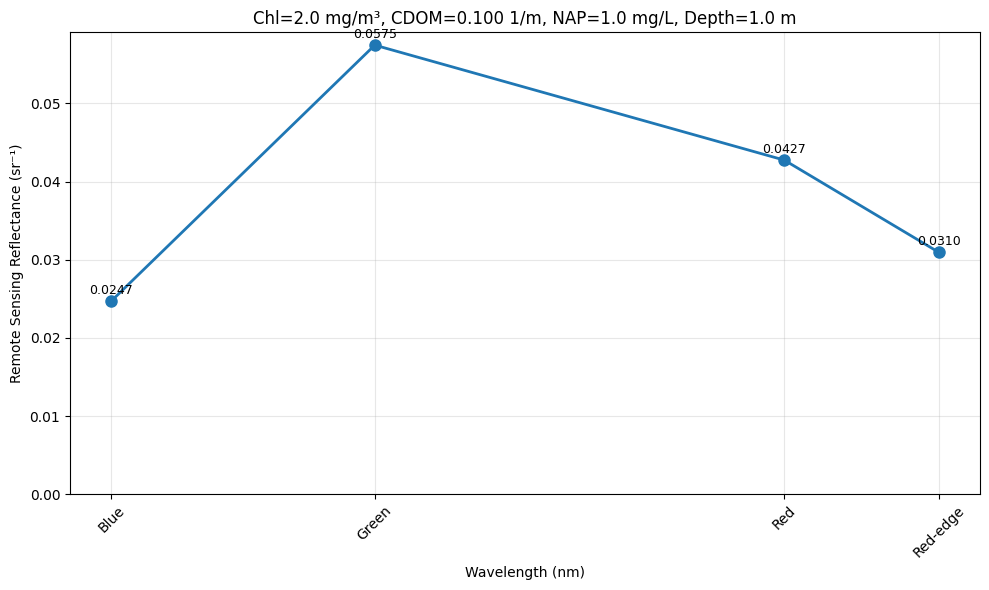

In [13]:
# Create an interactive exploration function
def explore_parameters(chl=2.0, cdom=0.1, nap=1.0, depth=5.0):
    """
    Interactive function to explore parameter effects.
    You can adjust the parameters using sliders (if using ipywidgets).
    """
    
    # Run forward model
    results = sbc.forward_model(
        chl=chl, cdom=cdom, nap=nap, depth=depth,
        substrate1=substrate1,
        wavelengths=wavelengths,
        a_water=a_water,
        a_ph_star=a_ph_star,
        num_bands=num_bands
    )
    
    # Create plot
    plt.figure(figsize=(10, 6))
    plt.plot(wavelengths, results.rrs, 'o-', linewidth=2, markersize=8)
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Remote Sensing Reflectance (sr⁻¹)')
    plt.title(f'Chl={chl:.1f} mg/m³, CDOM={cdom:.3f} 1/m, NAP={nap:.1f} mg/L, Depth={depth:.1f} m')
    plt.grid(True, alpha=0.3)
    plt.xticks(wavelengths, band_names, rotation=45)
    plt.ylim(0, None)
    
    # Show numerical values
    for i, (wl, rrs) in enumerate(zip(wavelengths, results.rrs)):
        plt.text(wl, rrs + 0.0005, f'{rrs:.4f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    return results

# Try the function with different parameters
print("🎮 Try changing these parameters to see how they affect the spectrum:")

# Example calls (you can modify these values)
print("\n1. Baseline case:")
baseline = explore_parameters(chl=2.0, cdom=0.1, nap=1.0, depth=5.0)

print("\n2. High chlorophyll:")
high_chl = explore_parameters(chl=8.0, cdom=0.1, nap=1.0, depth=5.0)

print("\n3. Shallow water:")
shallow = explore_parameters(chl=2.0, cdom=0.1, nap=1.0, depth=1.0)

In [14]:
# Try to create interactive widgets if ipywidgets is available
try:
    from ipywidgets import interact, FloatSlider
    
    print("🎛️ Interactive controls available! Use the sliders below:")
    
    # Create interactive version
    interact(explore_parameters,
             chl=FloatSlider(min=0.1, max=10.0, step=0.1, value=2.0, description='Chlorophyll (mg/m³)'),
             cdom=FloatSlider(min=0.01, max=1.0, step=0.01, value=0.1, description='CDOM (1/m)'),
             nap=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='NAP (mg/L)'),
             depth=FloatSlider(min=0.5, max=20.0, step=0.5, value=5.0, description='Depth (m)'))
    
except ImportError:
    print("📝 ipywidgets not available. You can still modify the parameters manually in the code above.")
    print("To install: pip install ipywidgets")

📝 ipywidgets not available. You can still modify the parameters manually in the code above.
To install: pip install ipywidgets


## 7. Summary and Next Steps

Congratulations! 🎉 You've completed the Sambuca Core getting started tutorial. Here's what you've learned:

### What You've Accomplished:

1. ✅ **Set up** Sambuca Core and ran your first forward model
2. ✅ **Understood** how water properties affect satellite observations
3. ✅ **Explored** parameter sensitivity through visualization
4. ✅ **Learned** about SIOPs and spectral libraries
5. ✅ **Performed** your first inversion to retrieve water properties
6. ✅ **Analyzed** inversion results and spectral fitting

### Key Concepts:

- **Forward Model**: Predicts satellite observations from water properties
- **Inversion**: Derives water properties from satellite observations
- **SIOPs**: Spectral Inherent Optical Properties that define how water components absorb and scatter light
- **Parameter Sensitivity**: Understanding which wavelengths are most sensitive to different water properties

### Next Steps:

1. **Run the Examples**: Try the example scripts in the `examples/` directory:
   - `01_basic_forward_model_example.py`
   - `02_siop_and_sensor_example.py`
   - `03_simple_inversion_example.py`
   - `04_advanced_image_processing_example.py`

2. **Process Real Data**: Try processing actual satellite imagery

3. **Explore Advanced Features**:
   - Look-up tables for faster processing
   - Uncertainty estimation
   - Multi-start optimization
   - Custom objective functions

4. **Learn More**:
   - Read the scientific literature on bio-optical modeling
   - Explore different sensor configurations
   - Experiment with different water types

### Resources:

- **Documentation**: Check the `docs/` directory
- **Examples**: All example scripts have detailed comments
- **Tests**: Look at test files for more usage examples
- **GitHub Issues**: Ask questions or report problems

### Happy Remote Sensing! 🛰️🌊

Remember: The ocean is complex, but with tools like Sambuca, we can better understand and monitor our blue planet!

In [15]:
# Final check - print summary statistics
print("TUTORIAL COMPLETION SUMMARY")
print("=" * 40)
print(f"✅ Forward model runs completed")
print(f"✅ Parameter sensitivity explored")
print(f"✅ Inversion performed successfully")
print(f"✅ Results visualized and analyzed")
print("\n🎓 You're ready to explore Sambuca Core further!")
print("\n📚 Next: Try running the example scripts or processing real satellite data.")

TUTORIAL COMPLETION SUMMARY
✅ Forward model runs completed
✅ Parameter sensitivity explored
✅ Inversion performed successfully
✅ Results visualized and analyzed

🎓 You're ready to explore Sambuca Core further!

📚 Next: Try running the example scripts or processing real satellite data.
